# Compare Sonnet vs Chronos2 (zero-shot)

This notebook performs a brief 10-epoch training run for Sonnet and conducts zero-shot inference with Chronos2 using a rolling-window evaluation. It reports Correlation, MAE, MSE, RMSE, and a modified SMAPE at the target forecasting horizon.

Notes:
- For zero-shot Chronos, the input context is the entire dataset before the desired output sequence.

In [ ]:
# First, install required packages
!pip install PrettyTable chronos-forecasting

In [ ]:
from types import SimpleNamespace
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import lightning as L
from prettytable import PrettyTable

from chronos import Chronos2Pipeline
from sonnet.data.weatherDataloader import CustomWeatherDataModule, get_weather_paths
from sonnet.model_config import ModelConfig

In [ ]:
# Parameters 
city_year = 'london_2018'   # format: city_endYear
model_key = 'sonnet'        
batch_size = 64
seq_length = 28
pred_length = 4
epochs = 10
lr = 1e-3
weight_decay = 1e-8
out_prefix = 'london'
chronos_limit = None


In [ ]:
def build_datamodule(city_year: str, batch_size: int, seq_length: int, pred_length: int):
    params = dict(
        seq_length=seq_length,
        pred_length=pred_length,
        scale=True,
        task='MB',
        target_column='t850',
        start_year=1980,
    )
    dm = CustomWeatherDataModule(city_year, batch_size=batch_size, **params)
    dm.setup()
    return dm


In [ ]:
def build_model(model_name: str, dm, seq_length: int, pred_length: int, lr: float, weight_decay: float):
    from hydra import initialize_config_dir, compose
    from omegaconf import OmegaConf

    cfg_dir = os.path.join(os.getcwd(), 'configs')
    with initialize_config_dir(config_dir=cfg_dir, version_base=None):
        cfg = compose(config_name='config', overrides=[f'model={model_name}'])
    yaml_model_params = OmegaConf.to_container(cfg.model.model_params, resolve=True) if hasattr(cfg.model, 'model_params') else {}

    model_cfg = {
        **yaml_model_params,
        'seq_len': seq_length,
        'pred_len': pred_length,
        'enc_in': dm.num_variables,
        'dec_in': dm.num_variables,
        'seasonality': None,
        'data_group': 'weatherbench',
        'c_out': 1,
    }

    configs = SimpleNamespace(**model_cfg)
    model_reg = ModelConfig(name=model_name)
    ModelClass = model_reg.model_class

    exp_params = {
        'lr': lr,
        'weight_decay': weight_decay,
        'lr_scheduler': 'cosine_lr',
        'reverse_eval': False,
    }

    model = ModelClass(configs, datamodule=dm, **exp_params)
    return model


In [ ]:
def inference_collect_last(model, dm, device):
    model = model.to(device)
    model.eval()

    loader = dm.test_dataloader()
    preds = []
    trues = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            out = model(x)
            out = out.cpu().numpy()
            y = y.cpu().numpy()

            if out.ndim == 3:
                preds.extend(out[:, -1, -1].tolist())
                trues.extend(y[:, -1, -1].tolist())
            else:
                preds.extend(out[:, -1].tolist())
                trues.extend(y[:, -1].tolist())

    preds = np.array(preds)
    trues = np.array(trues)

    if dm.scaler is not None:
        try:
            preds = dm.scaler.inverse_transform(preds.reshape(-1, 1)).reshape(-1)
            trues = dm.scaler.inverse_transform(trues.reshape(-1, 1)).reshape(-1)
        except Exception:
            print('Inverse transform failed; keeping scaled values')

    timestamps = dm.dates_iso[: len(preds)]
    df = pd.DataFrame({'timestamp': pd.to_datetime(timestamps), 'pred_last': preds, 'true_last': trues})
    return df


In [6]:
def run_chronos_rolling(raw_csv_path: str, target_column: str, target_timestamps, prediction_length: int, out_prefix: str, pipeline=None, limit=None, hours_per_step: int = 6):
    if pipeline is None:
        pipeline = Chronos2Pipeline.from_pretrained('amazon/chronos-2', device_map='cuda')

    raw = pd.read_csv(raw_csv_path, index_col=0)
    raw.index = pd.to_datetime(raw.index)

    results = []
    total = len(target_timestamps)
    if limit is not None:
        total = min(total, int(limit))

    for i, ts in enumerate(target_timestamps[:total]):
        target_ts = pd.to_datetime(ts)
        origin_time = target_ts - pd.Timedelta(hours=hours_per_step * prediction_length)

        history = raw.loc[:origin_time].copy()

        context_df = history[[target_column]].reset_index().rename(columns={history.index.name or 'index': 'timestamp', target_column: 'target'})
        context_df['id'] = 'series_0'
        context_df = context_df[['id', 'timestamp', 'target']]

        pred_df = pipeline.predict_df(
            context_df,
            prediction_length=prediction_length,
            quantile_levels=[0.1, 0.5, 0.9],
            id_column='id',
            timestamp_column='timestamp',
            target='target',
        )

        true_val = raw.loc[target_ts, target_column]
        pred_val = pred_df['predictions'][prediction_length-1]
        results.append({'timestamp': target_ts, 'pred_last': pred_val, 'true_last': true_val})

        if (i + 1) % 10 == 0 or (i + 1) == total:
            print(f'Chronos rolling: processed {i+1}/{total} origins')

    df_res = pd.DataFrame(results)
    return df_res

In [ ]:
dm = build_datamodule(city_year, batch_size, seq_length, pred_length)

model = build_model(model_key, dm, seq_length, pred_length, lr, weight_decay)

devices = 1
trainer = L.Trainer(max_epochs=epochs, accelerator='auto', devices=devices, enable_checkpointing=False, logger=False)
print(f'Starting training for {epochs} epochs...')
trainer.fit(model, dm.train_dataloader(), dm.val_dataloader())

print('Running inference on test set (Sonnet)...')
df_sonnet = inference_collect_last(model, dm, torch.device('cuda' if torch.cuda.is_available() else 'cpu'))


In [15]:
sonnet_corr = np.corrcoef(df_sonnet['pred_last'], df_sonnet['true_last'])[0, 1]
sonnet_mae = np.mean(np.abs(df_sonnet['pred_last'] - df_sonnet['true_last']))
sonnet_mse = np.mean((df_sonnet['pred_last'] - df_sonnet['true_last']) ** 2)
sonnet_rmse = np.sqrt(np.mean((df_sonnet['pred_last'] - df_sonnet['true_last']) ** 2))
a = np.min(df_sonnet['true_last']) + 30
sonnet_smape = 100.0 * np.mean(2.0 * np.abs(df_sonnet['pred_last'] - df_sonnet['true_last']) / (np.abs(df_sonnet['pred_last'] - a) + np.abs(df_sonnet['true_last'] - a) + 1e-8))

# prettytable
table = PrettyTable()
table.field_names = ["Model", "Correlation", "MAE", "MSE", "RMSE", "SMAPE"]
table.add_row(["Sonnet", f"{sonnet_corr:.6f}", f"{sonnet_mae:.6f}", f"{sonnet_mse:.6f}", f"{sonnet_rmse:.6f}", f"{sonnet_smape:.6f}"])
print(table)

+--------+-------------+----------+----------+----------+-----------+
| Model  | Correlation |   MAE    |   MSE    |   RMSE   |   SMAPE   |
+--------+-------------+----------+----------+----------+-----------+
| Sonnet |   0.920714  | 1.781907 | 5.689457 | 2.385258 | 23.297455 |
+--------+-------------+----------+----------+----------+-----------+


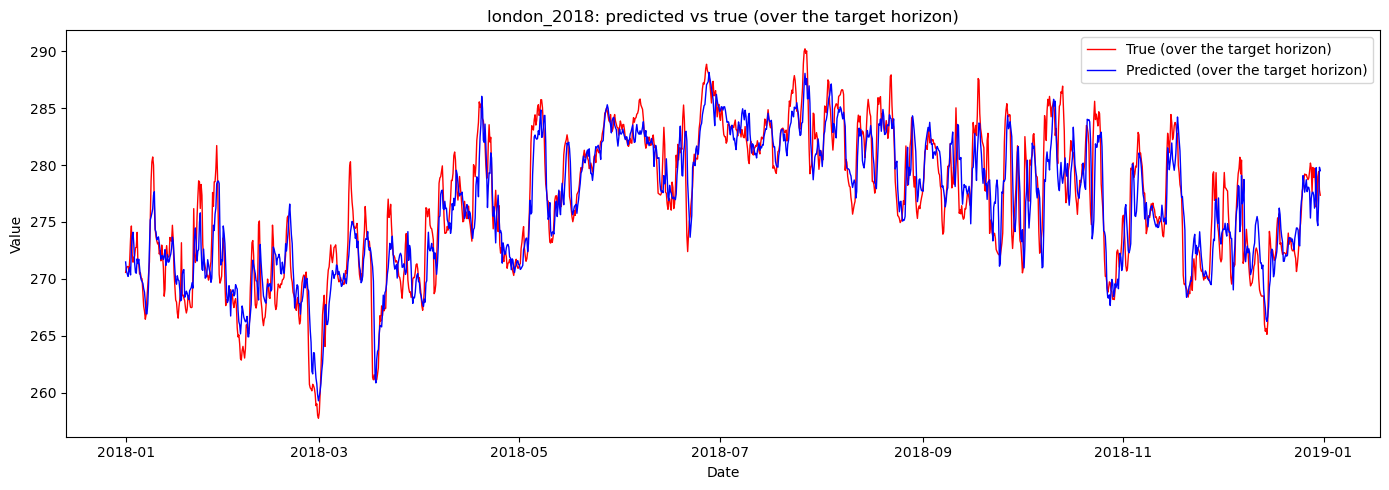

In [9]:
plt.figure(figsize=(14, 5))
plt.plot(df_sonnet['timestamp'], df_sonnet['true_last'], label='True (over the target horizon)', color='red', linewidth=1)
plt.plot(df_sonnet['timestamp'], df_sonnet['pred_last'], label='Predicted (over the target horizon)', color='blue', linewidth=1)
plt.xlabel('Date')
plt.ylabel('Value')
plt.title(f"{city_year}: predicted vs true (over the target horizon)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
path = get_weather_paths(city_year.split('_')[0])
df_chronos = run_chronos_rolling(path, 't850', dm.dates_iso, pred_length, out_prefix, limit=chronos_limit)

In [16]:
chronos_corr = np.corrcoef(df_chronos['pred_last'], df_chronos['true_last'])[0, 1]
chronos_mae = np.mean(np.abs(df_chronos['pred_last'] - df_chronos['true_last']))
chronos_mse = np.mean((df_chronos['pred_last'] - df_chronos['true_last']) ** 2)
chronos_rmse = np.sqrt(np.mean((df_chronos['pred_last'] - df_chronos['true_last']) ** 2))
chronos_smape = 100.0 * np.mean(2.0 * np.abs(df_chronos['pred_last'] - df_chronos['true_last']) / (np.abs(df_chronos['pred_last'] - a) + np.abs(df_chronos['true_last'] - a) + 1e-8))

# prettytable
table = PrettyTable()
table.field_names = ["Model", "Correlation", "MAE", "MSE", "RMSE", "SMAPE"]
table.add_row(["Chronos2", f"{chronos_corr:.6f}", f"{chronos_mae:.6f}", f"{chronos_mse:.6f}", f"{chronos_rmse:.6f}", f"{chronos_smape:.6f}"])
print(table)

+----------+-------------+----------+-----------+----------+-----------+
|  Model   | Correlation |   MAE    |    MSE    |   RMSE   |   SMAPE   |
+----------+-------------+----------+-----------+----------+-----------+
| Chronos2 |   0.853841  | 2.426568 | 10.207077 | 3.194852 | 29.459991 |
+----------+-------------+----------+-----------+----------+-----------+


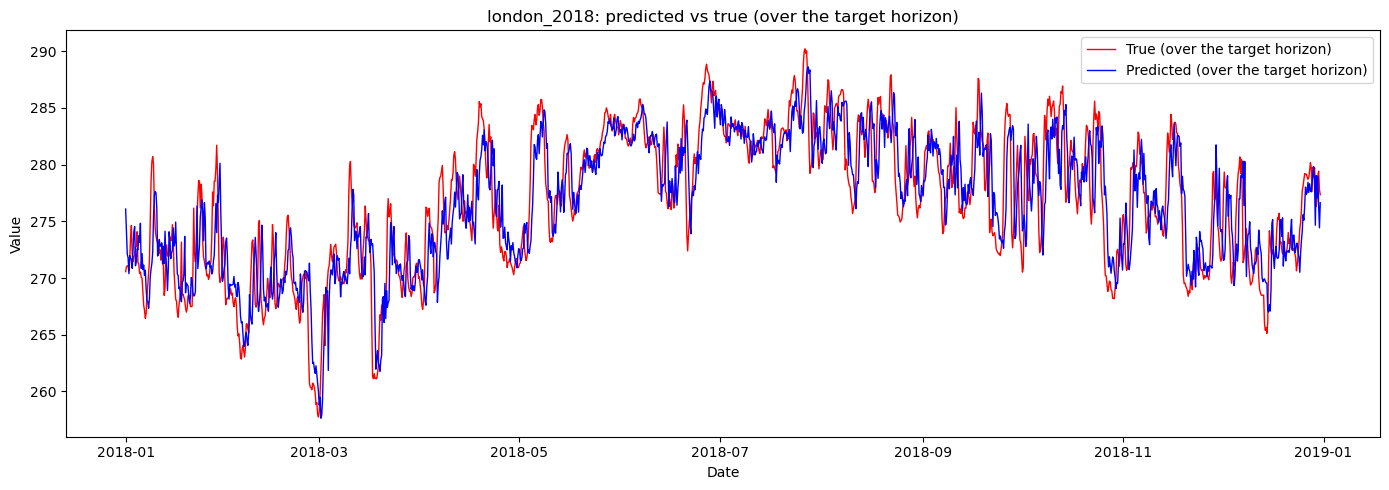

In [12]:
plt.figure(figsize=(14, 5))
plt.plot(df_chronos['timestamp'], df_chronos['true_last'], label='True (over the target horizon)', color='red', linewidth=1)
plt.plot(df_chronos['timestamp'], df_chronos['pred_last'], label='Predicted (over the target horizon)', color='blue', linewidth=1)
plt.xlabel('Date')
plt.ylabel('Value')
plt.title(f"{city_year}: predicted vs true (over the target horizon)")
plt.legend()
plt.tight_layout()
plt.show()